<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week7/Week_7_Spring2026_Part1_Linear_Regression_Diagnostics__Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Diagnostics (1 Class)
This notebook supports a 75-minute lesson on using **EDA + residual plots** to diagnose:
- Missing **nonlinear terms** (e.g., polynomial)
- Needed **transformations** (e.g., log)
- Missing **interactions** (effect of X depends on Z)

## Bridging for R users
You already know `lm()`, residual plots, and AIC/BIC. This notebook uses Python equivalents:
- `lm(y ~ x + z)` ↔ `statsmodels.OLS(y, X).fit()`
- `plot(resid(m) ~ fitted(m))` ↔ residuals-vs-fitted scatterplot
- `AIC(m)` / `BIC(m)` ↔ `m.aic` / `m.bic`

**Workflow stays the same:** fit baseline → diagnose → propose change → validate with AIC/BIC and better residuals.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

np.random.seed(7)
plt.rcParams['figure.dpi'] = 120


## 1. Teaching dataset (curvature + interaction + funnel-shaped noise)
We simulate data so the diagnostic patterns are easy to see.
In class you can swap in a real dataset; the diagnostic steps remain identical.

In [2]:
n = 250
x = np.random.uniform(1, 10, size=n)
z = np.random.choice(['A','B'], size=n)

# True signal: curvature + interaction
beta0, beta1, beta2 = 5, 2.0, -0.12
int_effect = np.where(z=='B', 1.2, 0.0)
signal = beta0 + (beta1 + int_effect)*x + beta2*(x**2)

# Heteroskedastic noise (funnel)
eps = np.random.normal(0, 0.6 + 0.25*x, size=n)
y = signal + eps

df = pd.DataFrame({'y': y, 'x': x, 'z': z})
df.head()

,y,x,z
0,7.638062,1.686775,A
1,18.460810,8.019269,B
2,20.441607,4.945683,B
3,25.541872,7.511187,B
4,24.108708,9.801906,B


### R equivalent
```r
# df <- data.frame(y=y, x=x, z=z)
```

## 2. EDA: y vs x (look for curvature)
Add a LOESS smooth to see the relationship shape.

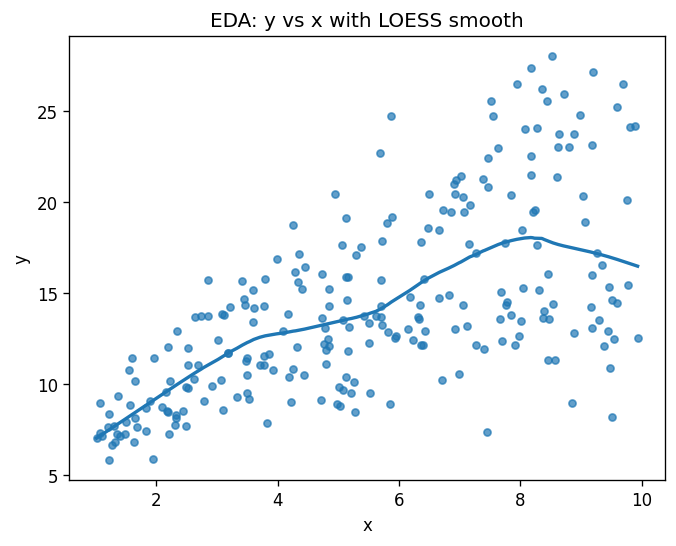

In [3]:
plt.figure()
plt.scatter(df['x'], df['y'], s=18, alpha=0.7)
smth = lowess(df['y'], df['x'], frac=0.35, return_sorted=True)
plt.plot(smth[:,0], smth[:,1], linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('EDA: y vs x with LOESS smooth')
plt.show()

**Interpretation:** clear curvature suggests trying `x^2` (polynomial) or a transform such as `log(x)`.

### R equivalent
```r
# plot(y ~ x, data=df)
# lines(lowess(df$x, df$y), lwd=2)
```

## 3. Baseline model + diagnostics
Baseline model (no interaction, no curvature): **y ~ x + z**

In [4]:
df2 = pd.get_dummies(df, columns=['z'], drop_first=True)  # z_B indicator
df2['z_B'] = df2['z_B'].astype(int) # Explicitly convert boolean to int
X0 = sm.add_constant(df2[['x','z_B']])
m0 = sm.OLS(df2['y'], X0).fit()
print(m0.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     422.4
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.92e-80
Time:                        00:18:34   Log-Likelihood:                -575.37
No. Observations:                 250   AIC:                             1157.
Df Residuals:                     247   BIC:                             1167.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         


### R equivalent
```r
# m0 <- lm(y ~ x + z, data=df)
# summary(m0)
```

### Residuals vs fitted (look for funnel / shape)

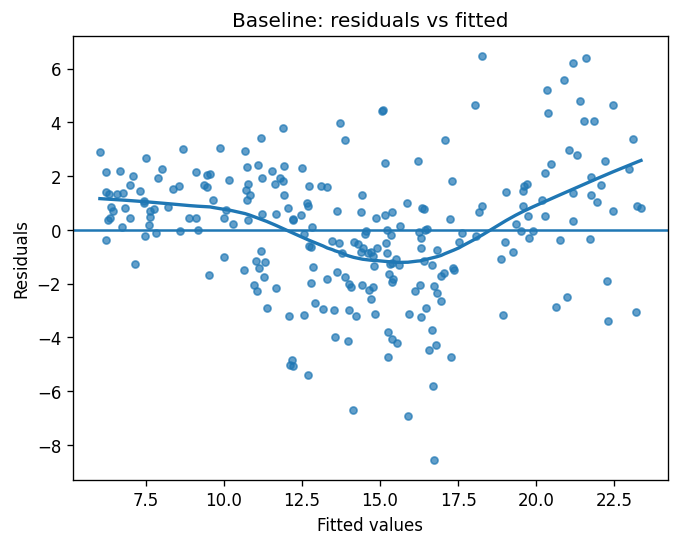

In [5]:
fitted0, resid0 = m0.fittedvalues, m0.resid
plt.figure()
plt.scatter(fitted0, resid0, s=18, alpha=0.7)
smth_rvf = lowess(resid0, fitted0, frac=0.4, return_sorted=True)
plt.plot(smth_rvf[:,0], smth_rvf[:,1], linewidth=2)
plt.axhline(0)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Baseline: residuals vs fitted')
plt.show()

### Residuals vs x (look for curvature)

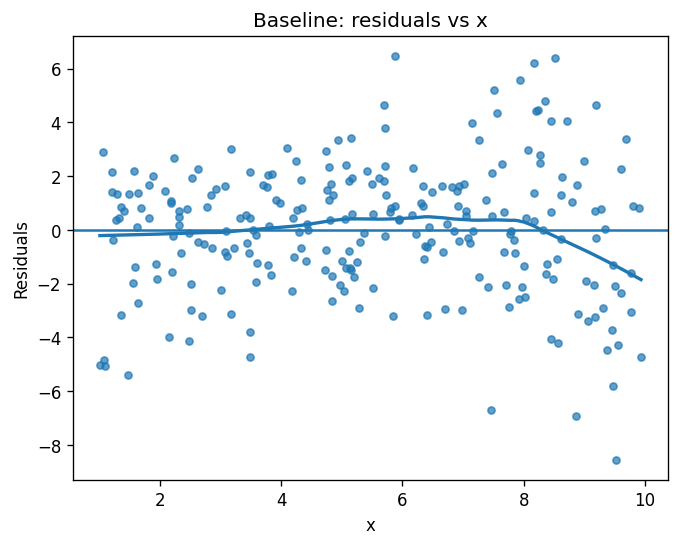

In [6]:
plt.figure()
plt.scatter(df2['x'], resid0, s=18, alpha=0.7)
smth_rvx = lowess(resid0, df2['x'], frac=0.4, return_sorted=True)
plt.plot(smth_rvx[:,0], smth_rvx[:,1], linewidth=2)
plt.axhline(0)
plt.xlabel('x')
plt.ylabel('Residuals')
plt.title('Baseline: residuals vs x')
plt.show()

### R equivalent residual plots
```r
# plot(resid(m0) ~ fitted(m0))
# abline(h=0)
# plot(resid(m0) ~ x, data=df)
# abline(h=0)
```

## 4. EDA + residuals for interactions
Look for different slopes by group in EDA, then confirm using residuals-by-group after fitting a model without interaction.

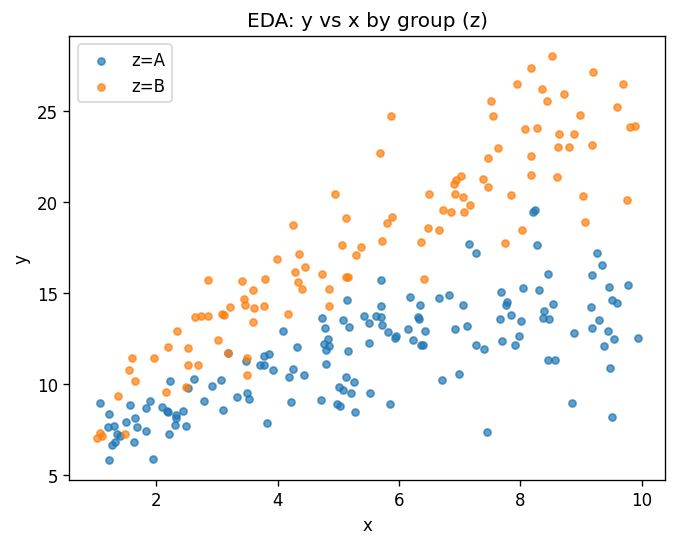

In [7]:
plt.figure()
for label, g in df.groupby('z'):
    plt.scatter(g['x'], g['y'], s=18, alpha=0.7, label=f'z={label}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('EDA: y vs x by group (z)')
plt.legend()
plt.show()

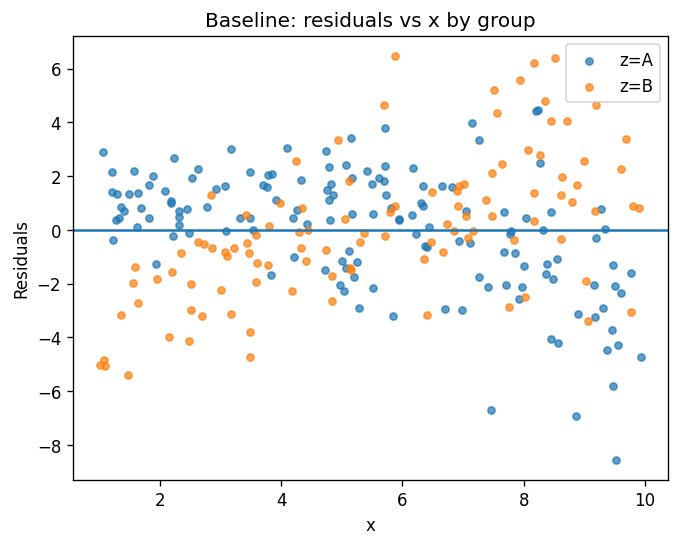

In [8]:
plt.figure()
tmp = df2.copy()
tmp['z'] = df['z']
tmp['resid'] = resid0
for label, g in tmp.groupby('z'):
    plt.scatter(g['x'], g['resid'], s=18, alpha=0.7, label=f'z={label}')
plt.axhline(0)
plt.xlabel('x')
plt.ylabel('Residuals')
plt.title('Baseline: residuals vs x by group')
plt.legend()
plt.show()

### R equivalents
```r
# plot(y ~ x, col=z, data=df)
# plot(resid(m0) ~ x, col=z, data=df)
```

## 5. Propose fixes (polynomial, interaction) and validate with AIC/BIC
We compare a small set of models motivated by diagnostics:
- `m1`: add curvature (`x^2`)
- `m2`: add interaction (`x:z`)
- `m3`: add both


In [9]:
df2['x2'] = df2['x']**2
df2['xzB'] = df2['x'] * df2['z_B']

X1 = sm.add_constant(df2[['x','x2','z_B']])
m1 = sm.OLS(df2['y'], X1).fit()

X2 = sm.add_constant(df2[['x','z_B','xzB']])
m2 = sm.OLS(df2['y'], X2).fit()

X3 = sm.add_constant(df2[['x','x2','z_B','xzB']])
m3 = sm.OLS(df2['y'], X3).fit()

compare = pd.DataFrame({
    'model': ['m0: y~x+z', 'm1: +x^2', 'm2: +x:z', 'm3: +x^2 + x:z'],
    'AIC': [m0.aic, m1.aic, m2.aic, m3.aic],
    'BIC': [m0.bic, m1.bic, m2.bic, m3.bic]
}).sort_values('AIC')
compare

,model,AIC,BIC
3,m3: +x^2 + x:z,1049.086830,1066.694135
2,m2: +x:z,1068.335423,1082.421267
1,m1: +x^2,1146.834176,1160.920020
0,m0: y~x+z,1156.745247,1167.309630


### R equivalents
```r
# m1 <- lm(y ~ x + I(x^2) + z, data=df)
# m2 <- lm(y ~ x * z, data=df)
# m3 <- lm(y ~ x * z + I(x^2), data=df)
# AIC(m0, m1, m2, m3)
# BIC(m0, m1, m2, m3)
```

## 6. Re-check diagnostics on the chosen model
Pick the model that improves AIC/BIC **and** removes patterns in residual plots.
Below we visualize residuals vs fitted for `m3` as a typical outcome.

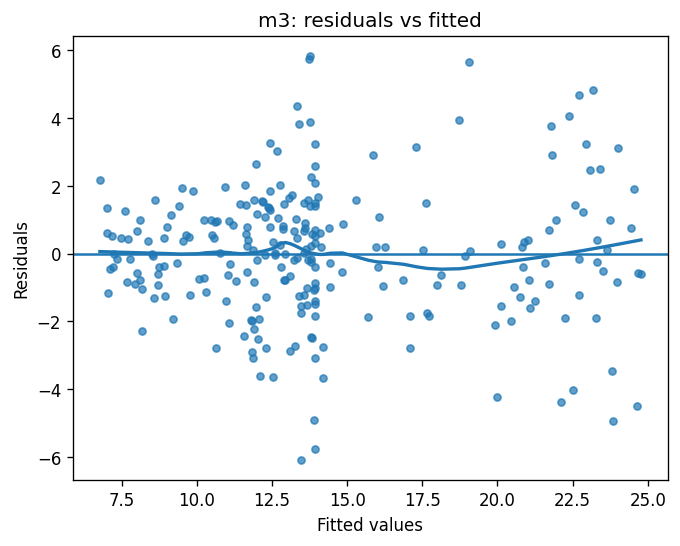

In [10]:
fitted3, resid3 = m3.fittedvalues, m3.resid
plt.figure()
plt.scatter(fitted3, resid3, s=18, alpha=0.7)
smth3 = lowess(resid3, fitted3, frac=0.4, return_sorted=True)
plt.plot(smth3[:,0], smth3[:,1], linewidth=2)
plt.axhline(0)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('m3: residuals vs fitted')
plt.show()

## 7. Optional: log-transform y if the funnel remains
If residual spread increases with fitted values, a transformation of `y` may help.
For teaching, we use a safe shift so the log is defined.

In [11]:
y_shift = df2['y'] - df2['y'].min() + 1
df2['logy'] = np.log(y_shift)
m4 = sm.OLS(df2['logy'], X3).fit()

pd.DataFrame({'model':['m3 on y','m4 on log(y)'], 'AIC':[m3.aic, m4.aic], 'BIC':[m3.bic, m4.bic]})

,model,AIC,BIC
0,m3 on y,1049.086830,1066.694135
1,m4 on log(y),55.995618,73.602923


### R equivalent
```r
# df$logy <- log(df$y - min(df$y) + 1)
# m4 <- lm(logy ~ x * z + I(x^2), data=df)
```

## Exit ticket (concept check)
Answer briefly:
1) Curved residuals vs x suggests what type of fix?
2) Funnel residuals vs fitted suggests what type of fix?
3) What EDA pattern suggests an interaction between x and z?
4) Why should AIC/BIC validate a *small set* of diagnostic-motivated models rather than guide blind searching?
